In [16]:
# Python essential libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit
import astropy.units as u
import astropy.constants as const

from lmfit.lineshapes import gaussian

# Defining my matplotlib canvas template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen', 'orange']),
                     'font.family':'serif', 'font.serif': 'Times New Roman', 'mathtext.rm': 'serif',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

#### Sampling

In [81]:
exposure_time = 3 * u.year
exposure_time_in_surveys = exposure_time / 2 * u.year
eff_area = 80/6 * 46134950 * u.cm**2 * u.s * exposure_time_in_surveys       # From cosipy 1154-1160 keV response. I have extrapolated this to +/- 40 keV (search key: "window")
num_photons = A * 1e-6 * eff_area
num_photons = num_photons.value.round().astype(int)
photons = np.random.choice(xdata, num_photons, p=signal/np.sum(signal))

<ErrorbarContainer object of 3 artists>

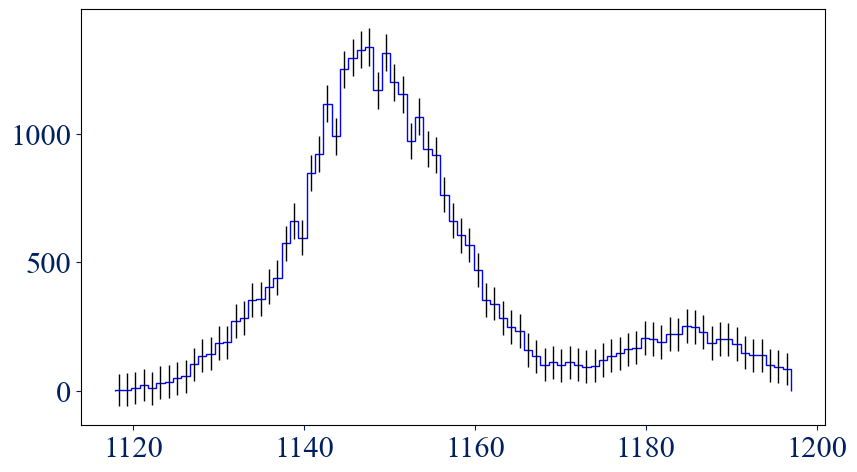

In [82]:
num_bins = 80
counts, bins, _ = plt.hist(photons, bins=num_bins + 1, histtype='step')
bg_counts_per_bin = num_photons * 10 / num_bins      # Bg counts: signal counts :: 10:1
counts_err = np.sqrt(counts + bg_counts_per_bin)
plt.errorbar(bins[:-1] + np.diff(bins)/2, counts, yerr=counts_err, fmt=' ', c='k', alpha=1, lw=1)

In [87]:
a_coeff

{(0, 0): 1.1495230418950244,
 (1, -1): 0.5583429357869574,
 (1, 0): 0.5298174499576005,
 (1, 1): -0.6204396958125452,
 (2, -2): 0.750974723079381,
 (2, -1): -0.7705154774508932,
 (2, 0): -0.5822056290902354,
 (2, 1): -0.5688947490195514,
 (2, 2): 0.8516034670909689,
 (3, -3): -1.057177611589414,
 (3, -2): 0.18036960224673582,
 (3, -1): -0.07019425306694399,
 (3, 0): 0.7886747765429293,
 (3, 1): -0.44958989929844373,
 (3, 2): 0.4141025214279,
 (3, 3): 0.6281216154320386,
 (4, -4): -0.4343546531907076,
 (4, -3): 0.37771345622604285,
 (4, -2): 0.03816031663445011,
 (4, -1): -0.24592577895739423,
 (4, 0): -0.6749593237031616,
 (4, 1): -0.20864658686257767,
 (4, 2): -0.2954644097396542,
 (4, 3): -0.001844995515439752,
 (4, 4): 0.05097220128090697,
 (5, -5): 0.27514199575642273,
 (5, -4): -0.34122587397173065,
 (5, -3): 0.36496647910085245,
 (5, -2): -0.1823768247072374,
 (5, -1): -0.17341070350791266,
 (5, 0): -0.21721094302287902,
 (5, 1): 0.20329967903165005,
 (5, 2): -0.01442934210111851

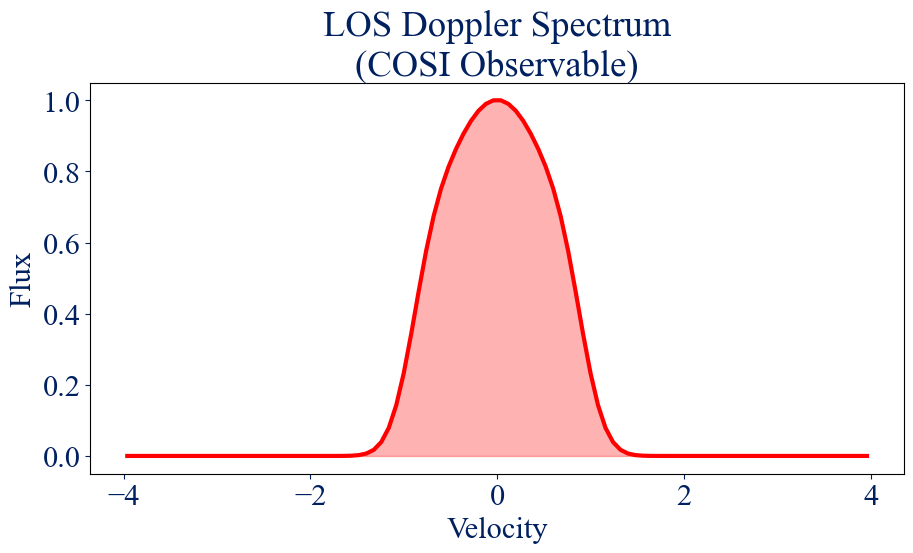

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

# -----------------------------
# Spherical grid
# -----------------------------
n_theta = 100
n_phi = 100

theta_1d = np.linspace(0, np.pi, n_theta)
phi_1d = np.linspace(0, 2 * np.pi, n_phi)
phi, theta = np.meshgrid(phi_1d, theta_1d)

# -----------------------------
# Real spherical harmonics
# -----------------------------
def Y_real(l, m, theta, phi):
    return sph_harm_y(m, l, theta, phi).real

def field(coeffs, theta, phi):
    f = np.zeros_like(theta)
    for (l, m), c in coeffs.items():
        f += c * Y_real(l, m, theta, phi)
    return f

# -----------------------------
# Random SH coefficients
# -----------------------------
def random_coeffs(lmax, alpha=2.0):
    """
    Draw Gaussian spherical harmonic coefficients with
    angular power spectrum C_l ∝ (l+1)^(-2 alpha).
    """
    coeffs = {}
    for l in range(lmax + 1):
        sigma = 1.0 / (l + 1) ** alpha
        for m in range(-l, l + 1):
            coeffs[(l, m)] = np.random.normal(scale=sigma)
    return coeffs

a_coeff = {(0,0): 1} #random_coeffs(8, alpha=0.6)

# -----------------------------
# Inner ejecta surface
# -----------------------------
A_ang = field(a_coeff, theta, phi)
rA = 1.0 + 0.3 * A_ang

# -----------------------------
# 3D Cartesian grid
# -----------------------------
n = 80
x = np.linspace(-3, 3, n)
y = np.linspace(-3, 3, n)
z = np.linspace(-3, 3, n)
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

R = np.sqrt(X**2 + Y**2 + Z**2)
TH = np.arccos(np.clip(Z / (R + 1e-8), -1, 1))
PH = np.arctan2(Y, X)

# -----------------------------
# LOS Doppler spectrum from A
# -----------------------------
A_cart = np.zeros_like(R)
for (l, m), c in a_coeff.items():
    A_cart += c * Y_real(l, m, TH, PH)

v_los = 1 * X  # LOS = x-axis; 1 = v ∝ x

rA_interp = RegularGridInterpolator((phi_1d, theta_1d), rA)
rA_cart = rA_interp(
    np.stack([np.mod(PH, 2 * np.pi).ravel(), TH.ravel()], -1)
).reshape(R.shape)

mask = R < rA_cart
flux = np.clip(A_cart, 0, None) * mask

v = np.linspace(-4, 4, 101)
spec, _ = np.histogram(v_los.ravel(), bins=v, weights=flux.ravel())
dv = v[1] - v[0]
sigma_bins = 0.2 / dv
spec = gaussian_filter(spec, sigma_bins)
spec /= spec.max()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9.6, 6))
v_cen = (v[1:] + v[:-1]) / 2
ax.plot(v_cen, spec, color="r")
ax.fill_between(v_cen, spec, color="r", alpha=0.3)
ax.set_title("LOS Doppler Spectrum\n(COSI Observable)")
ax.set_xlabel("Velocity")
ax.set_ylabel("Flux")
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
from scipy.special import sph_harm_y
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

import spherical
import quaternionic

# ── Grid ──
theta_1d = np.linspace(0, np.pi, 120)
phi_1d   = np.linspace(0, 2 * np.pi, 240)
THETA, PHI = np.meshgrid(theta_1d, phi_1d)

# ── Build surfaces ──
def spherical_to_cartesian(Y, THETA, PHI):
    return (Y * np.sin(THETA) * np.cos(PHI),
            Y * np.sin(THETA) * np.sin(PHI),
            Y * np.cos(THETA))

def get_rotation_matrix(theta_rot, phi_rot):
    # Target direction in Cartesian
    n = np.array([np.sin(theta_rot)*np.cos(phi_rot), np.sin(theta_rot)*np.sin(phi_rot), np.cos(theta_rot)])
    R, _ = Rotation.align_vectors([n], [[0, 0, 1]])     # Rotate z-axis to vec n
    return R

    # Equivalent code for axisymmetric terms using Euler rotations. However, it will break if non-axisymmetric terms are used. 
    # return Rotation.from_euler('yz', [theta_rot, phi_rot])

In [2]:
def rotate_sph_harm(l, m_source, R, THETA, PHI):
    """
    Rotate Y_l^{m_source} to a new axis defined by rotation matrix R,
    re-expressed on the original (THETA, PHI) grid via Wigner D-matrix.

    Returns
    -------
    Y_rot  : (THETA, PHI) ndarray  — rotated harmonic (real)
    X_rot, Y_rot_c, Z_rot          — rotated Cartesian surface
    """
    # ── Quaternion from rotation matrix ──
    x, y, z, w = R.as_quat()   # scipy: scalar-last → quaternionic: scalar-first
    quat = quaternionic.array([w, x, y, z])

    # ── Wigner D-matrix ──
    wig = spherical.Wigner(l)
    D   = wig.D(quat)

    # ── Rotated harmonic: Ỹ_l^0 = Σ_{m'} D^(l)*_{m',0} · Y_l^{m'} ──
    Y_rot = np.zeros_like(THETA, dtype=complex)
    for mp in range(-l, l+1):
        D_coeff = D[wig.Dindex(l, mp, m_source)].conj()
        Y_rot  += D_coeff * sph_harm_y(l, mp, THETA, PHI)
    Y_rot = Y_rot.real

    return Y_rot

In [74]:
l, m = 0, 0

# Define rotation
theta_rot, phi_rot = np.pi/6, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_0_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_0_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_0_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_0_rot), THETA, PHI)

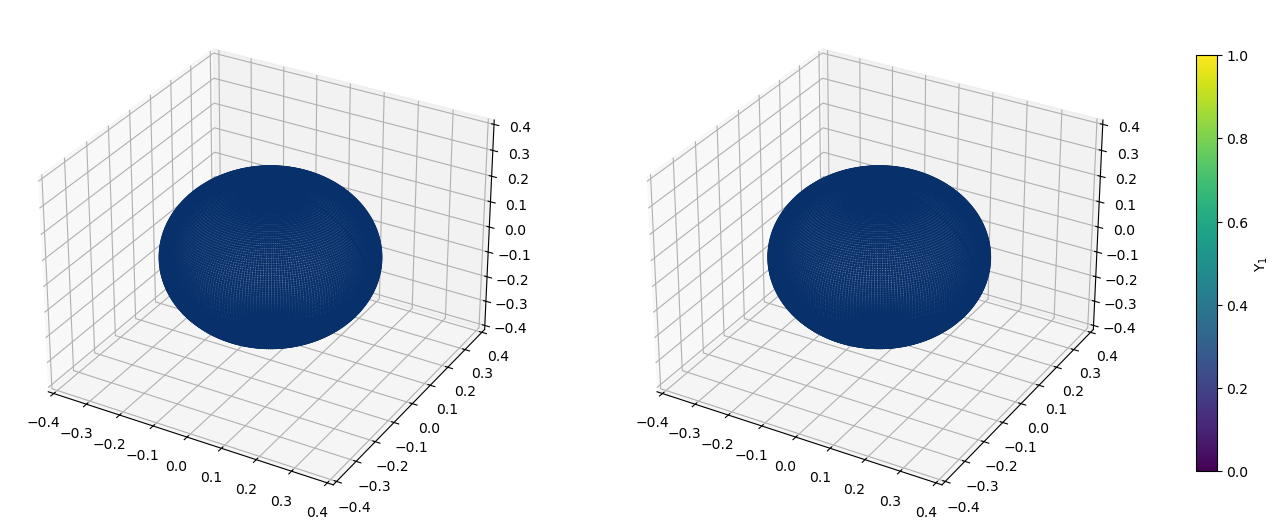

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, color=(0.0314, 0.188, 0.42))
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, color=(0.0314, 0.188, 0.42))
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

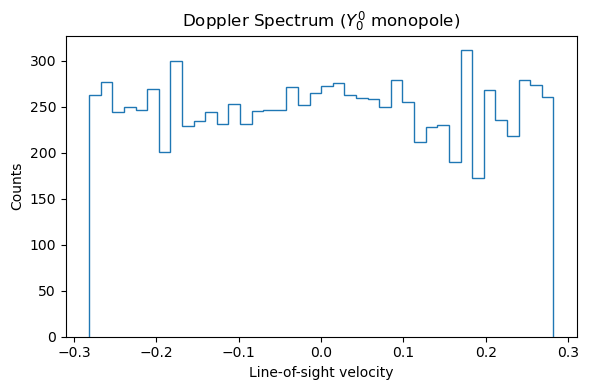

In [113]:
def doppler_spectrum(Z_cart, THETA, n_samples=10000, bins=50):
    """
    Sample Z_cart (line-of-sight velocities) weighted by solid angle sin(θ).
    
    Parameters
    ----------
    Z_cart    : 2D array — line-of-sight velocity at each (THETA, PHI) point
    THETA     : 2D array — polar angle grid
    n_samples : int     — number of Monte Carlo samples
    bins      : int     — number of histogram bins

    Returns
    -------
    bin_centers, counts
    """
    # Solid angle weight: sin(θ)
    weights = np.sin(THETA).ravel()
    weights /= weights.sum()                           # normalize to probability

    # Flat indices sampled according to solid angle
    indices = np.random.choice(Z_cart.size, size=n_samples, p=weights)

    # Sample velocities
    v_los = Z_cart.ravel()[indices]

    # Histogram → Doppler spectrum
    counts, bin_edges = np.histogram(v_los, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return bin_edges, counts


# ── Example ──
v_edges, counts = doppler_spectrum(Z_cart, THETA, bins=40)

plt.figure(figsize=(6, 4))
plt.stairs(counts, v_edges)
plt.xlabel("Line-of-sight velocity"); plt.ylabel("Counts")
plt.title("Doppler Spectrum ($Y_0^0$ monopole)")
plt.tight_layout()
plt.show()

In [13]:
l, m = 1, 0

# Define rotation
theta_rot, phi_rot = np.pi/6, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_1_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_1_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_1_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_1_rot), THETA, PHI)

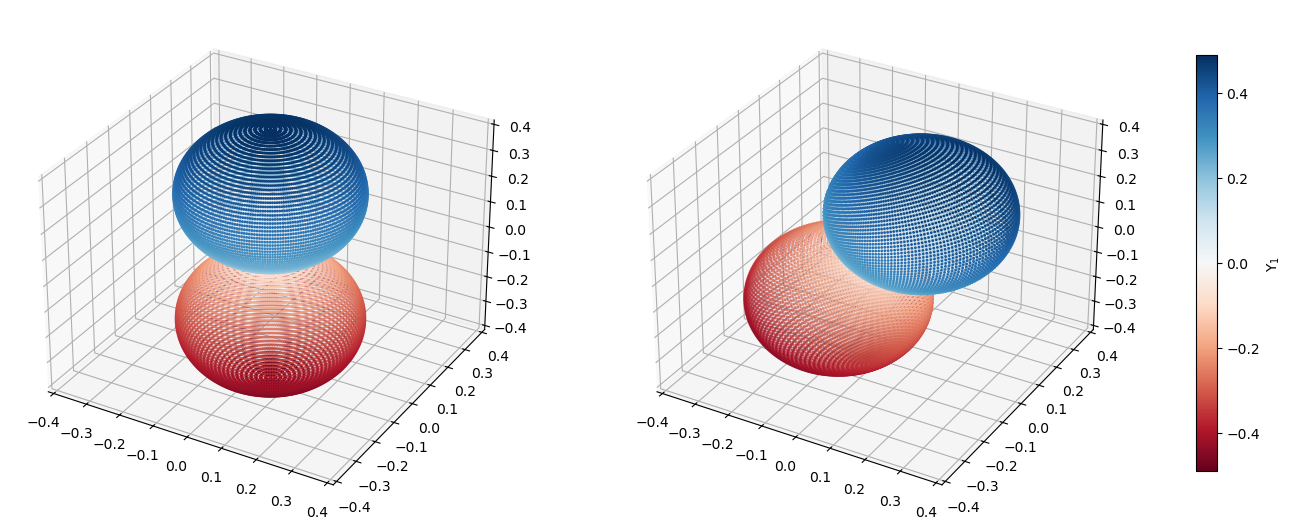

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_1_orig, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, c=Y_1_rot, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

In [38]:
l, m = 2, 0

# Define rotation
theta_rot, phi_rot = np.pi/8, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_2_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_2_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_2_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_2_rot), THETA, PHI)

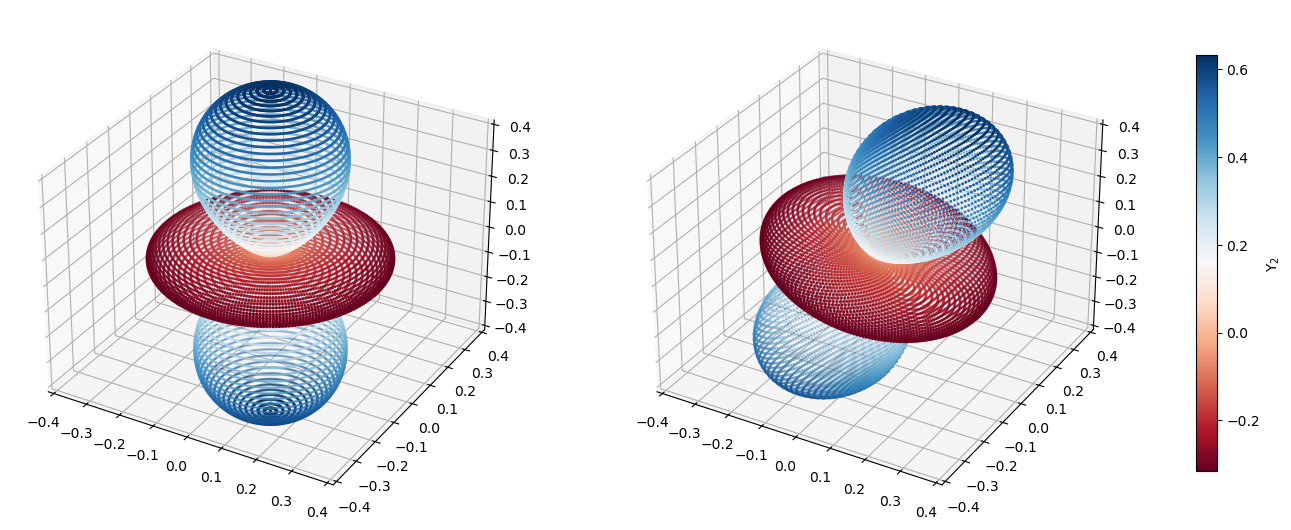

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_2_orig, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, c=Y_2_rot, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label=fr'Y$_{l}$')
plt.show()

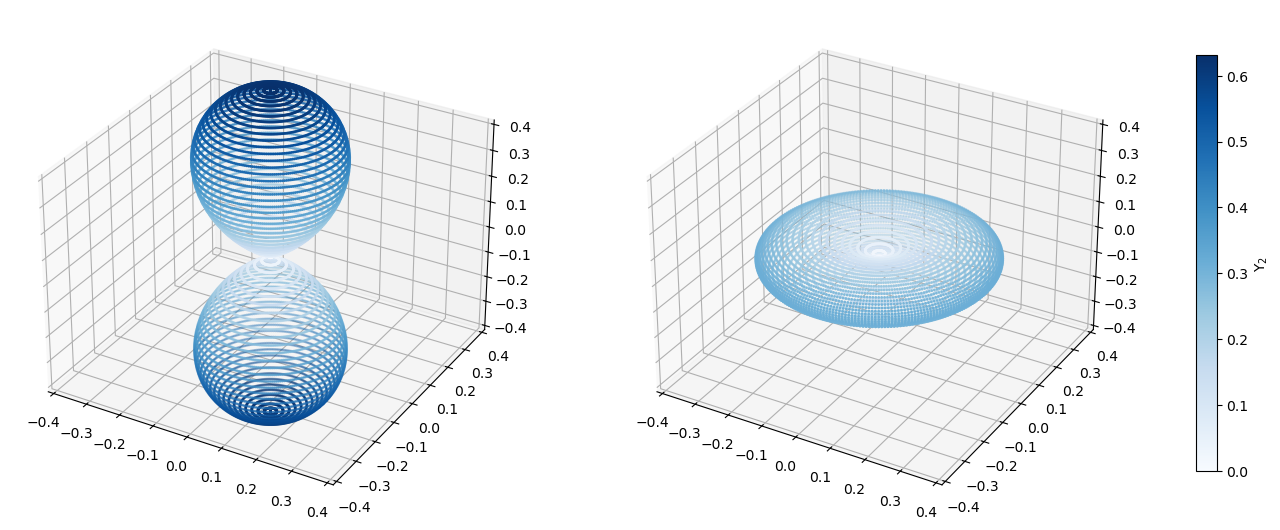

In [37]:
relative_strength = 1
a = 2 * relative_strength / (relative_strength + 1)     # jet
b = 2 / (relative_strength + 1)                         # disk   

from matplotlib.colors import Normalize

jet = np.where(Y_2_rot > 0, Y_2_rot, 0)   * a
disk = np.where(Y_2_rot < 0, -Y_2_rot, 0) * b

X_jet, Y_jet, Z_jet = spherical_to_cartesian(jet, THETA, PHI)
X_disk, Y_disk, Z_disk = spherical_to_cartesian(disk, THETA, PHI)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

vmin = 0
vmax = max(jet.max(), disk.max())
norm = Normalize(vmin=vmin, vmax=vmax)

sc = axs[0].scatter(X_jet, Y_jet, Z_jet, s=1, c=jet, cmap='Blues', norm=norm)
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_disk, Y_disk, Z_disk, s=1, c=disk, cmap='Blues', norm=norm)
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label=fr'Y$_{l}$')
plt.show()

##### Physical Frame Rotation Code

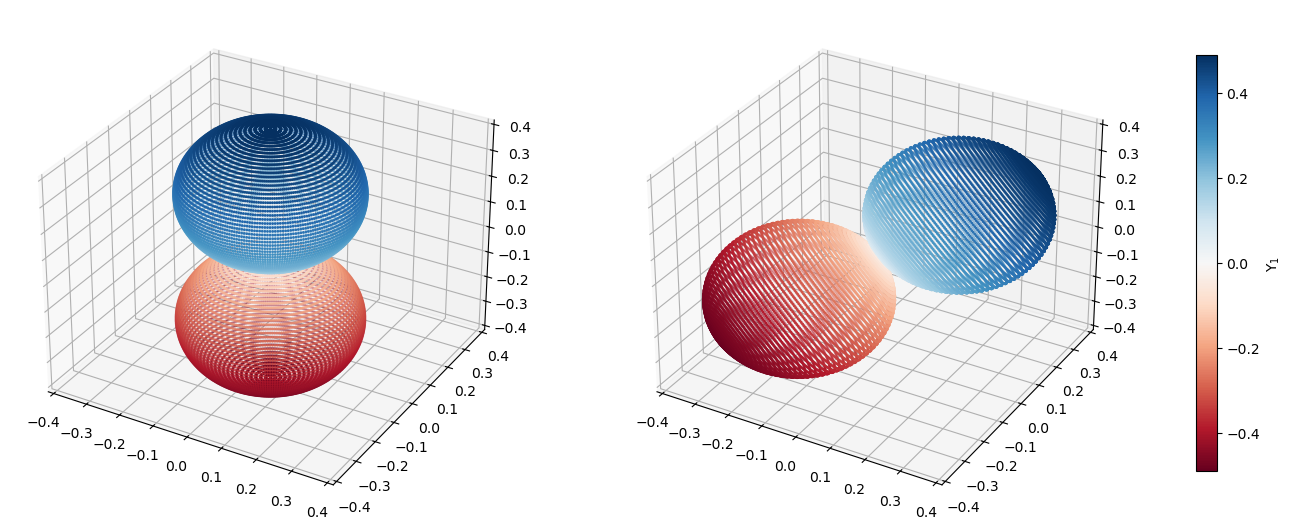

In [ ]:
# ── Y_1^0 (real part) as radial extent of velocities ──
Y_1 = sph_harm_y(1, 0, THETA, PHI).real   # signed, for colormap
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_1), THETA, PHI)

# Define rotation
theta_rot, phi_rot = np.pi/3, np.pi/4
R = get_rotation_matrix(theta_rot, phi_rot)

# Apply rotation
pts = np.stack([X_cart.ravel(), Y_cart.ravel(), Z_cart.ravel()])  # (3, N)
X_rot, Y_rot, Z_rot = (R.as_matrix() @ pts).reshape(3, *X_cart.shape)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_1, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_rot, Y_rot, Z_rot, s=1, c=Y_1, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

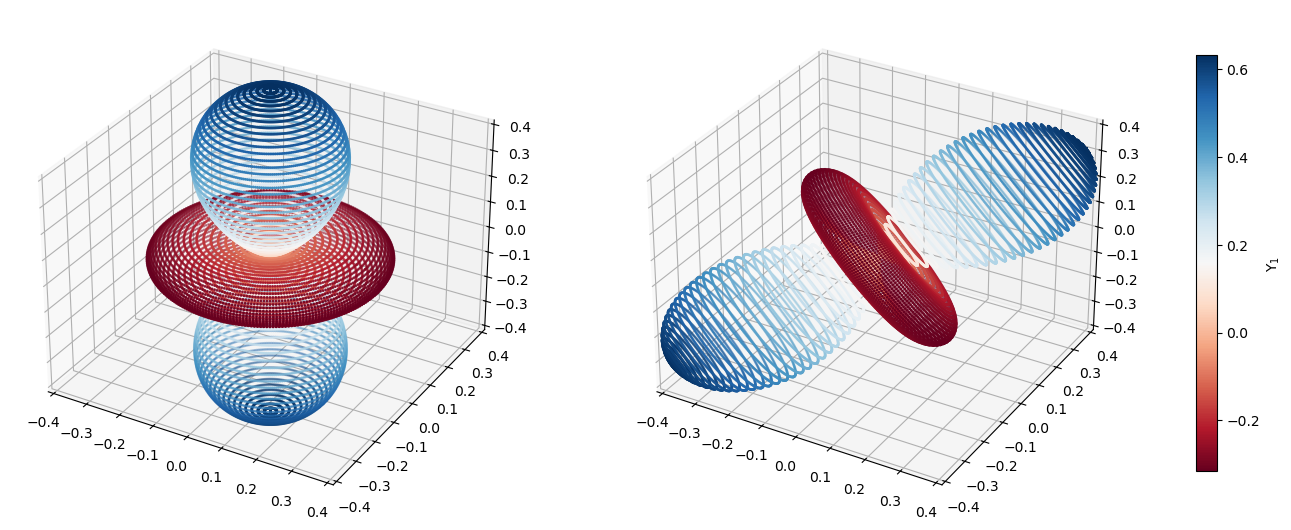

In [6]:
# ── Y_2^0 (real part) as radial extent of velocities ──
Y_2 = sph_harm_y(2, 0, THETA, PHI).real   # signed, for colormap
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_2), THETA, PHI)

# Define rotation
theta_rot, phi_rot = np.pi/3, np.pi/4
R = get_rotation_matrix(theta_rot, phi_rot)

# Apply rotation
pts = np.stack([X_cart.ravel(), Y_cart.ravel(), Z_cart.ravel()])  # (3, N)
X_rot, Y_rot, Z_rot = (R.as_matrix() @ pts).reshape(3, *X_cart.shape)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_2, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_rot, Y_rot, Z_rot, s=1, c=Y_2, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

#### Cas A G17

In [28]:
def gaussian(x, A, mu, sigma):
    return A / (np.sqrt(2 * np.pi) * sigma) * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [46]:
# System parameters
A = 35 * u.ph / u.cm**2 / u.s   # Amplitude of peak TODO: Depend on age, distance, and mass - only for Cas A
mu = 1157 * u.keV               # Line emission energy
fwhm = 7.5 * u.keV              # Instrumental line broadening (2.35 keV) # 9.1 keV, required performance; 5.3 keV, projected performance
sigma = fwhm / 2.355            # Converting to sigma, i.e., rms instrumental line broadening

In [18]:
# Function to calculate Doppler shifts
'''
vs towards the observer is negative
vs away from the observer is positive
For non-relativistic vs speeds
'''
def doppler_shift(E, vs):
    Eprime = const.c / (const.c + vs) * E
    return Eprime - E

# Linearly extrapolated version of Doppler broadening
# TODO: Verify correctness
'''
vmax is the highest absolute velocity of an 
expanding shell in the SN's rest frame
'''
# broadening = E0 * v/c
def doppler_broadening(E, vmax):
    # 3.86 keV for 1000 km/s
    # 1.93 keV for 500 km/s
    broadening = 3.86 * u.keV * (vmax / (1000 * u.km/u.s))
    return broadening

In [ ]:
1157 * u.keV * 1000 * u.km/u.s / const.c.to(u.km/u.s)

<Quantity 3.85940329 keV>

In [21]:
E = 1157.02 * u.keV
vs = 10000 * u.km/u.s
E + doppler_shift(E, vs)

<Quantity 1119.67176991 keV>

In [ ]:
fluxes = np.array([0.88, 1.23, 1.72, 1.13, 0.78, 1.25, 1.06, 0.64, 1.44, 0.96, 0.73]) * A.unit
centroids_68keV = np.array([67.35, 67.15, 69.5, 66.6, 67.6, 67.8, 67.8, 66.8, 67.4, 67.6, 67.1]) * u.keV
mu_68keV = 67.87 * u.keV
sigmas = np.array([5, 5, 15, 10, 15, 12, 12, 10, 11, 7, 5]) / 2 * u.keV

velocities = (const.c * (mu_68keV - centroids_68keV) / centroids_68keV).to(u.km/u.s)
centroids = mu + doppler_shift(mu, velocities)

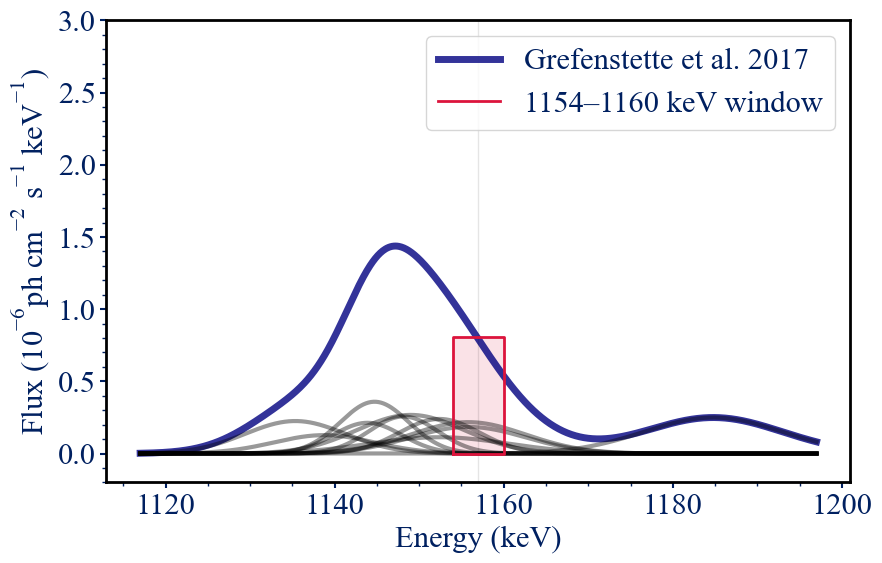

In [ ]:
# Updated Doppler broadening values with upper constraints from G16

binwidth = 0.1 * u.keV
window = 40 * u.keV
nbins = int(2 * window / binwidth) + 1
mu_xdata = mu
xdata = np.linspace(mu_xdata - window, mu_xdata + window, nbins)

# Scaling observed clumps by flux observed from SPI (Siegert et al 2015)
signal_by_clump = u.Quantity([gaussian(xdata, flux, cen, np.sqrt(Dop_sig**2 + sigma**2)) for flux, cen, Dop_sig in zip(fluxes*A/np.sum(fluxes), centroids, sigmas)])
signal = np.sum(signal_by_clump, axis=0)

plt.figure(figsize=(9.6, 6))
plt.plot(xdata, signal, label='Grefenstette et al. 2017', c='navy', alpha=0.8, lw=5, ls='solid', zorder=2)
for s in signal_by_clump:
    plt.plot(xdata, s, c='k', alpha=0.4, lw=3)
plt.axvline(x=mu.value, alpha=0.1, lw=1, c='k')

# box outline over [Emin, Emax] from y=0 to y=ymax_box
Emin, Emax = 1154 * u.keV, 1160 * u.keV
mask = (xdata >= Emin) & (xdata <= Emax)
# Integrated band flux (ph cm^-2 s^-1)
F_window = np.sum((signal * binwidth)[mask])
# Height on a phi(E) plot so rectangle area equals F_window
y_top = (F_window / (Emax - Emin)).to_value(u.ph / u.cm**2 / u.s / u.keV)
plt.plot(
    [Emin.value, Emax.value, Emax.value, Emin.value, Emin.value],
    [0, 0, y_top, y_top, 0],
    color='crimson', lw=2,
    label=f'{Emin.value:g}–{Emax.value:g} keV window',
)
plt.fill_between([Emin.value, Emax.value], 0, y_top, color='crimson', alpha=0.12)
# plt.text(
#     0.02, 0.55,
#     f'Integrated flux in window = {F_window.to("ph/(cm2 s)"):0.3g}',
#     transform=plt.gca().transAxes, va='top',
# )

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.gca().tick_params(width=1.5, length=4)
plt.gca().tick_params(which='minor', width=1, length=3)
plt.xlabel('Energy (keV)')
plt.ylabel('Flux ($\\mathregular{10^{-6}}$ph cm$\\mathregular{^{-2}}$ s$\\mathregular{^{-1}}$ keV$\\mathregular{^{-1}}$)')
plt.minorticks_on()
# plt.title('G17-like')
plt.ylim([-0.2,3])
plt.legend()
# plt.savefig('temp.png', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [30]:
np.sum(signal*binwidth)

<Quantity 34.65959966 ph / (s cm2)>

In [31]:
np.sum(signal_by_clump * binwidth)

<Quantity 34.65959966 ph / (s cm2)>

In [ ]:
from scipy.special import erf

# weights from your clump fluxes (only relative unless you also have an absolute total normalization)
w = (fluxes / np.sum(fluxes)).to_value(u.dimensionless_unscaled)

# Gaussian CDF fraction in [E1, E2] for each clump (area-normalized Gaussian)
z2 = ((Emax - centroids) / (np.sqrt(2) * sigmas)).to_value(u.dimensionless_unscaled)
z1 = ((Emin - centroids) / (np.sqrt(2) * sigmas)).to_value(u.dimensionless_unscaled)
frac_in_window_per_clump = 0.5 * (erf(z2) - erf(z1))  # unitless in [0,1]

# fraction of the *total* line flux that falls in 1154–1160 keV
frac_total_in_window = np.sum(w * frac_in_window_per_clump)

# if you know the absolute total line flux F_total (e.g. ph/cm2/s), get absolute flux in the window:
# F_window = frac_total_in_window * F_total
frac_total_in_window

In [ ]:
0.136 * 3.5e-5 * A.unit